In [3]:
result = {
    "Qwen2.5-Math-1.5B": {
        "in-domain": {
            "DIVER":32.2,
            "GPRO w/ Clip-higher":30.5
        },
        "out-of-domain": {
            "DIVER":41.4,
            "GPRO w/ Clip-higher":39.9
        },
    },
    
    "Qwen2.5-7B-Base": {
        "in-domain": {
            "DIVER":38.7,
            "GPRO w/ Clip-higher":37.0
        },
        "out-of-domain": {
            "DIVER":59.2,
            "GPRO w/ Clip-higher":57.9
        },
    },
    
    "LLaMA-3.1-8B-Instruct": {
        "in-domain": {
            "DIVER":23.1,
            "GPRO w/ Clip-higher":21.8
        },
        "out-of-domain": {
            "DIVER":53.5,
            "GPRO w/ Clip-higher":51.6
        },
    }
}

/tmp/ipykernel_46025/1956722917.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


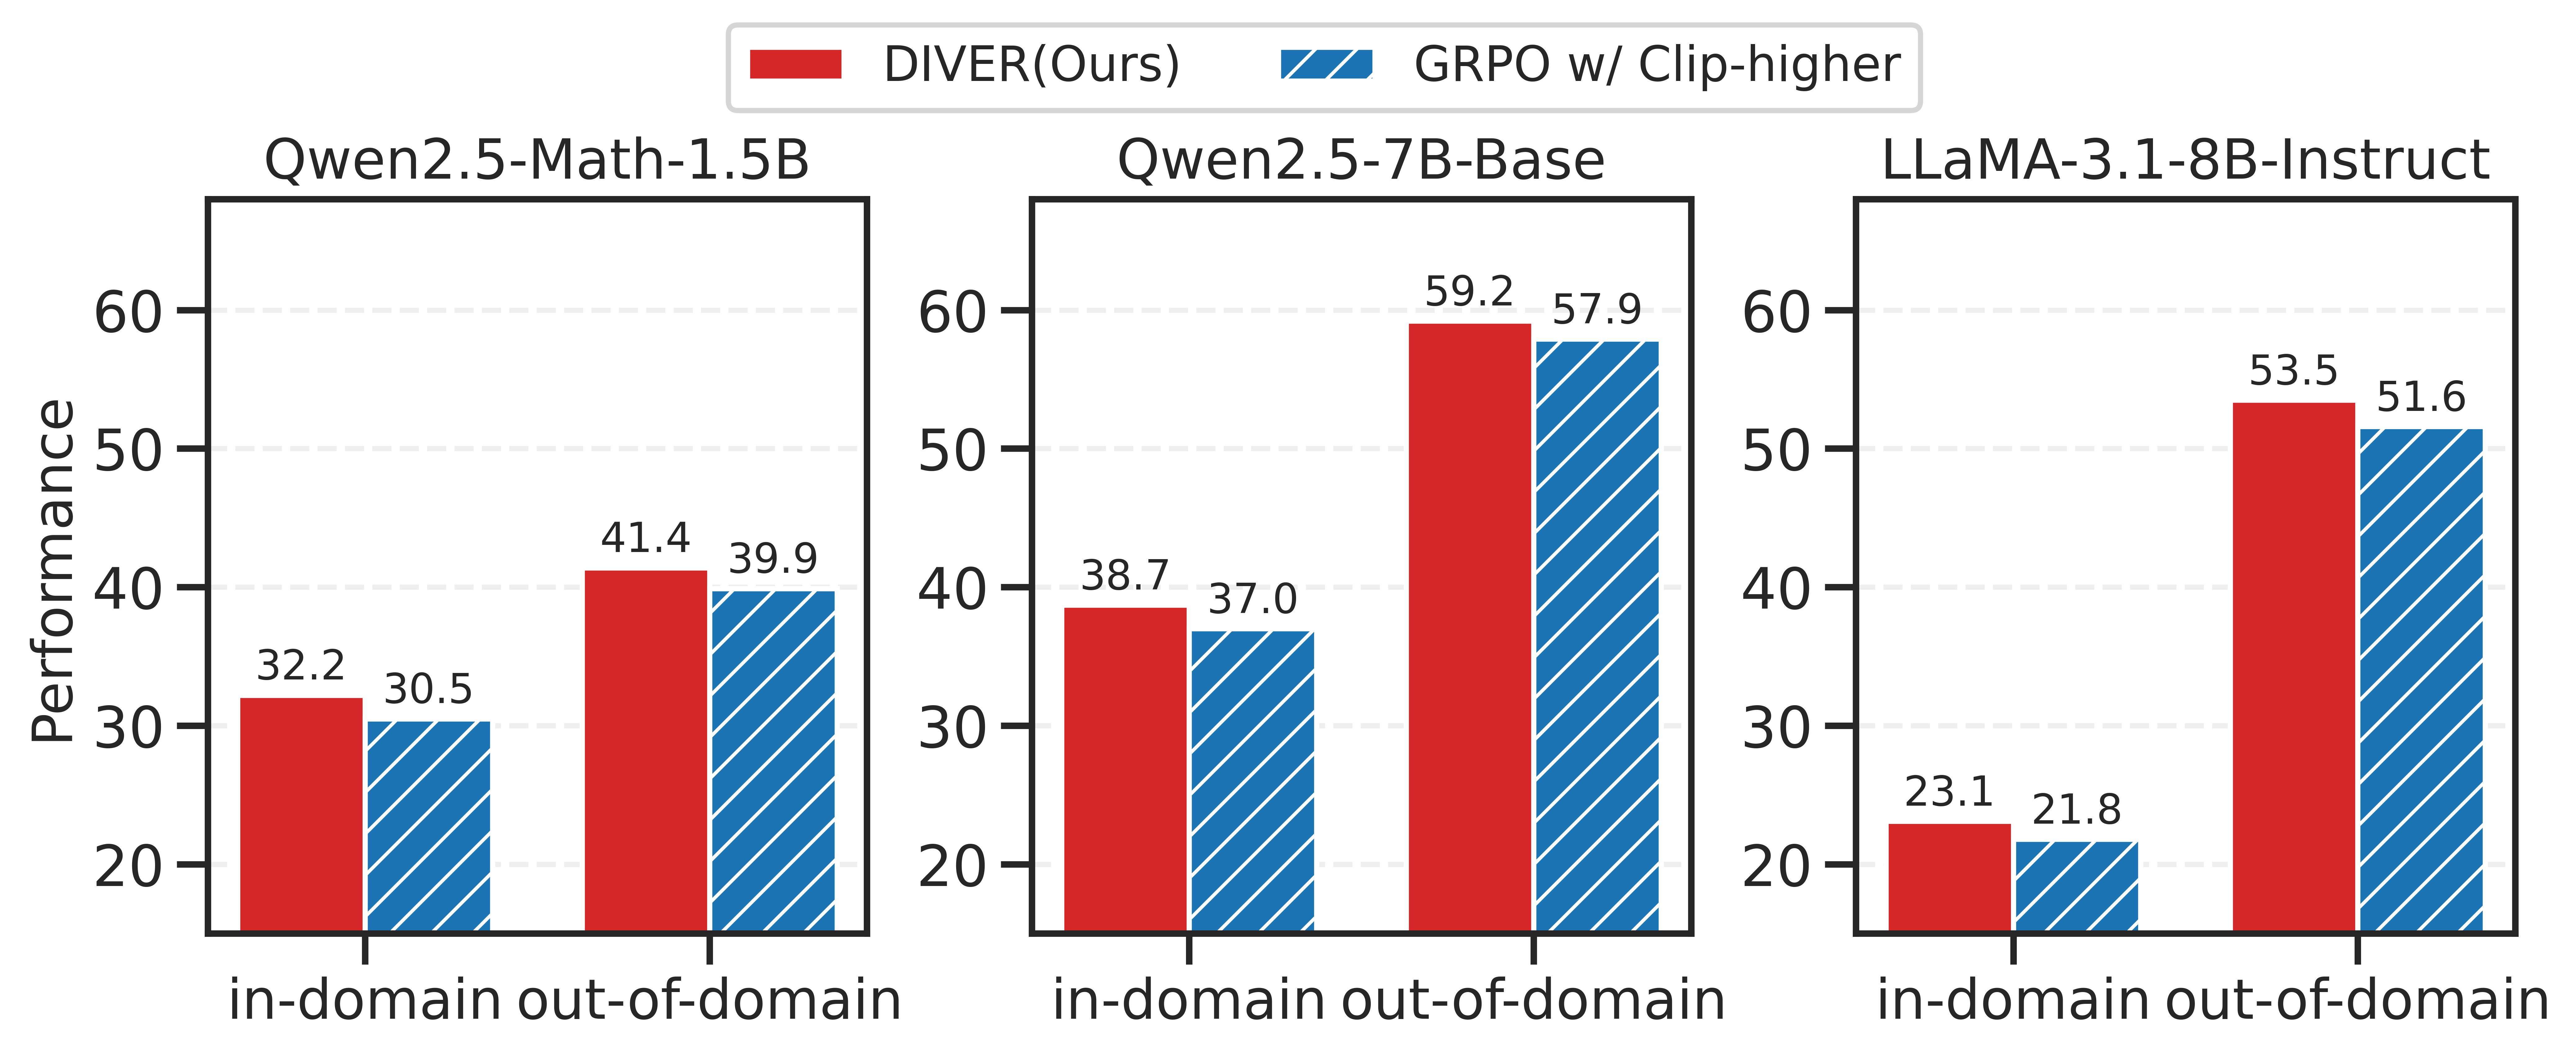

In [6]:
lengends = ["DIVER(Ours)","GRPO w/ Clip-higher"]
color = ['#D62728', '#1B75B4','#9467BD', '#2A9F2A','#7F7F7F','#E377C2','#FF7F0E']

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
sns.set_context('talk')

# Reduced figure width and adjusted spacing
fig = plt.figure(figsize=(12, 4), dpi=800)
Grid = plt.GridSpec(1, 3, wspace=0.25, hspace=0.2, width_ratios=[1, 1, 1])
plt.rcParams.update({'font.size': 20})

for sub_i, model in enumerate(result.keys()):
    sub_ax = plt.subplot(Grid[sub_i//3, sub_i%3])
    plt.title(f'{model}', fontsize=16)
    
    # Get the domains (in-domain and out-of-domain)
    domains = list(result[model].keys())
    
    # Get the methods (DIVER, GPRO w/ Clip-higher)
    methods = list(result[model][domains[0]].keys())
    
    # Set bar width and positions - increased width to fill more space
    bar_width = 0.37
    x = np.arange(len(domains))
    
    # Plot bars for each method
    for i, method in enumerate(methods):
        values = [result[model][domain][method] for domain in domains]
        bars = sub_ax.bar(x + i*bar_width - bar_width/2, values, width=bar_width, 
                color=color[i], label=lengends[i], hatch='//' if method!="DIVER" else '')
        
        # Add value labels on top of each bar
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if height > 0:  # Only add text if the bar has a non-zero height
                sub_ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=12)
    
    # Set x-axis labels and ticks with better formatting
    sub_ax.set_xticks(x)
    sub_ax.set_xticklabels(['in-domain', 'out-of-domain'], fontsize=16)
    
    # Set y-axis label
    if sub_i == 0:
        sub_ax.set_ylabel('Performance', fontsize=16)
    
    # Set y-axis limits - adjusted to better fit the data and leave space for labels
    sub_ax.set_ylim(15, 68)  # Increased upper limit to make room for text
    
    # Add grid for better readability
    sub_ax.grid(axis='y', linestyle='--', alpha=0.3)

# Create a single legend for the entire figure
handles, labels = sub_ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=2, fontsize=14, frameon=True)

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Make room for the legend at the top
# plt.show()
plt.savefig('./model_scale.pdf',bbox_inches='tight')